In [1]:
# 环境与依赖导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# 解决中文显示问题
matplotlib.rcParams["font.family"] = "SimHei"
matplotlib.rcParams["axes.unicode_minus"] = False

# 文件路径配置
INPUT_FILE = "../../2.预处理/惊蛰无声_cleaned.csv"
FONT_PATH  = "C:/Windows/Fonts/simhei.ttf"
RANDOM_STATE = 42

# 三类颜色方案
TYPE_META = {
    1:  {"label": "好评", "color": "#2ECC71", "cmap": "Greens"},
    0:  {"label": "中评", "color": "#F39C12", "cmap": "Oranges"},
    -1: {"label": "差评", "color": "#E74C3C", "cmap": "Reds"},
}

type_order = [1, 0, -1]
type_labels = [TYPE_META[t]["label"] for t in type_order]
type_colors_list = [TYPE_META[t]["color"] for t in type_order]

读取数据，隔离拆分好/差评

In [2]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
df["tokens"] = df["tokens"].fillna("")

# 将好评和差评拆分开来，分别建立 DataFrame
df_good = df[df["comment_type"] == 1].copy()
df_bad = df[df["comment_type"] == -1].copy()

print(f"总数据量：{len(df)}")
print(f"好评数据量：{len(df_good)} 条")
print(f"差评数据量：{len(df_bad)} 条")


总数据量：1193
好评数据量：400 条
差评数据量：396 条


## 1. 三类评论词云图

### 1.1 独立词云

分别统计好/中/差三类评论的词频，使用 `generate_from_frequencies` 生成词云，
横向 1×3 排列，配色与情感色调一致（绿 / 橙 / 红）。

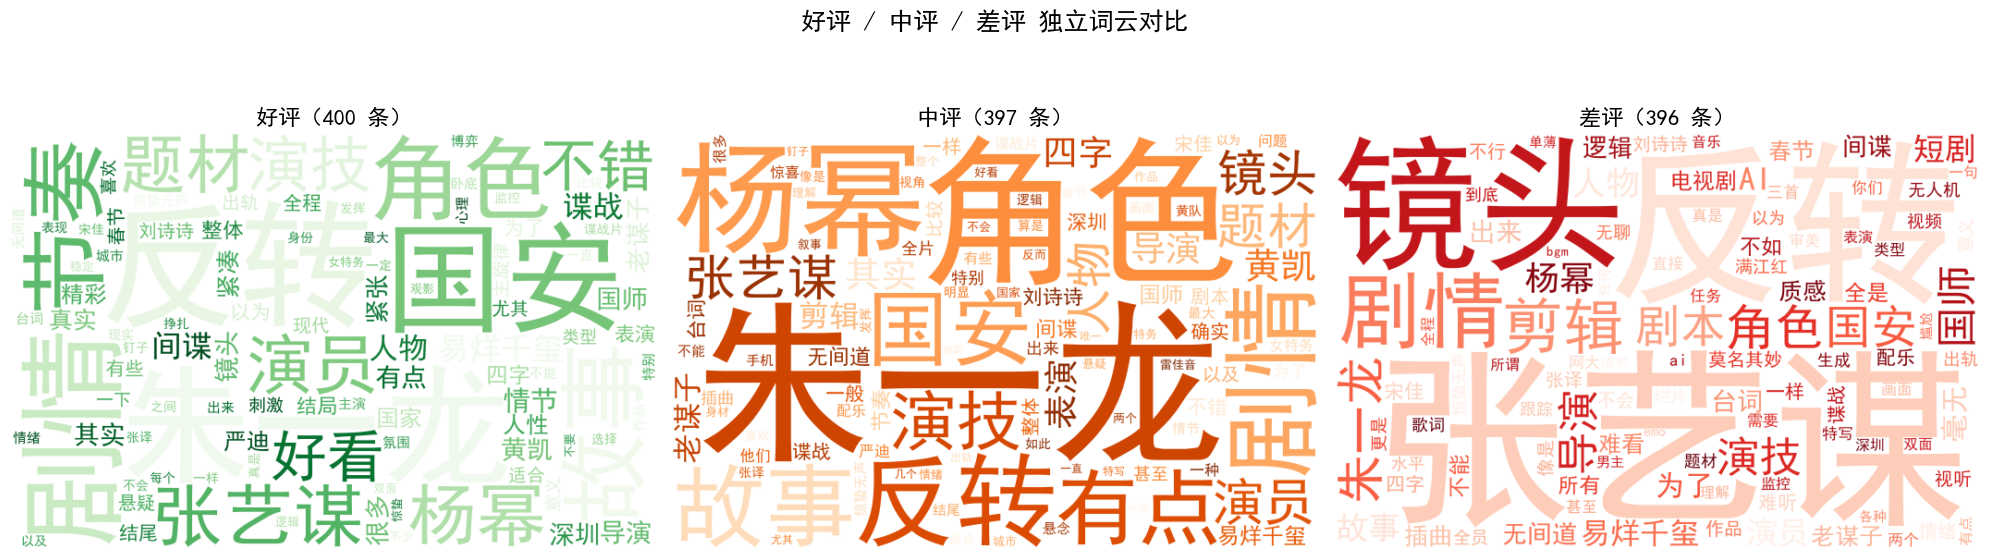

✅ 已保存：词云_三类对比.png


In [3]:
def get_word_freq(token_series):
    """统计分词结果中的词频"""
    all_words = " ".join(token_series).split()
    return Counter(all_words)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    subset = df[df["comment_type"] == t]
    freq = get_word_freq(subset["tokens"])
    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=100,
        colormap=meta["cmap"],
    ).generate_from_frequencies(freq)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]}（{len(subset)} 条）',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("好评 / 中评 / 差评 独立词云对比", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_三类对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_三类对比.png")

### 1.2 特征词词云（去除共有高频词）

对每类评论，用 TF-IDF 提取该类区分度最高的词，
只保留「本类独有」的表达，过滤掉三类共享的通用词。

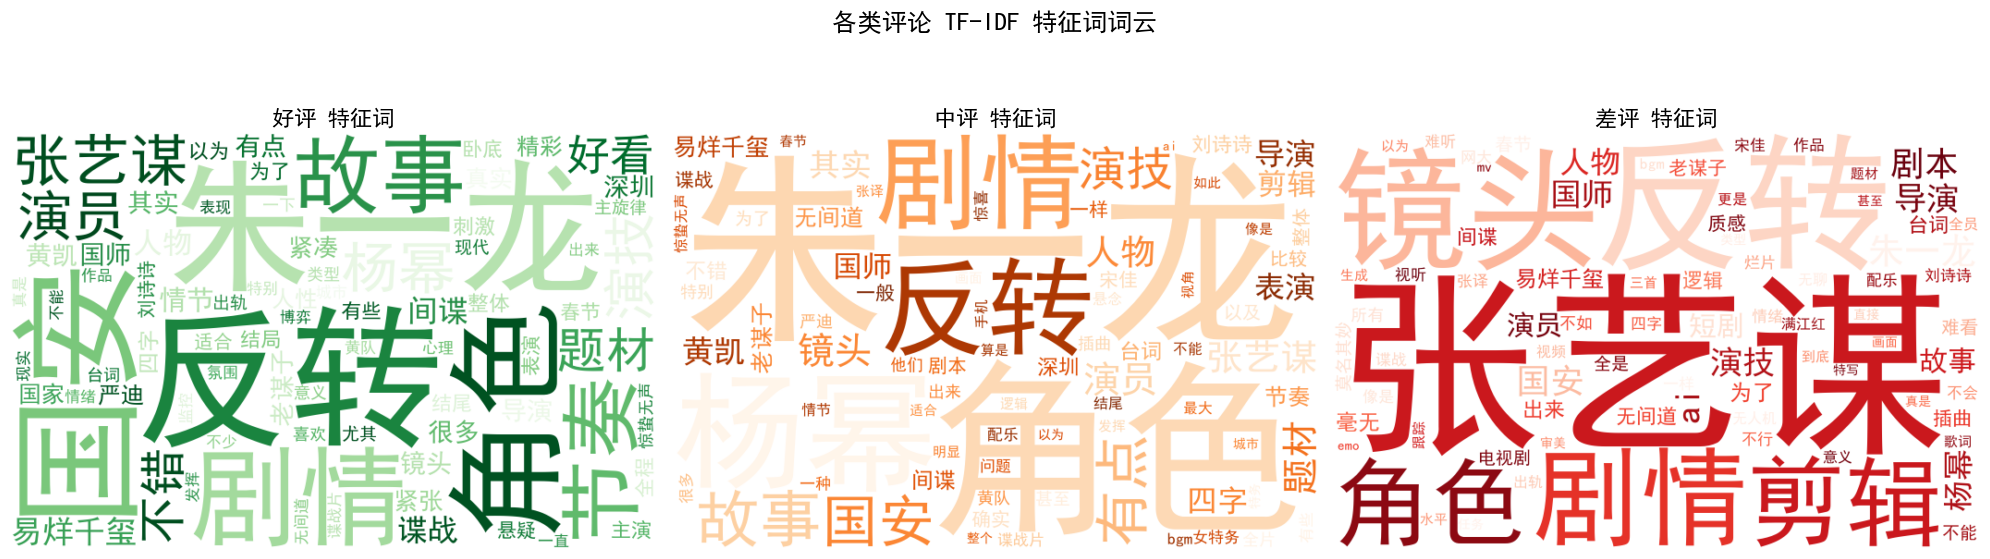

✅ 已保存：词云_特征词对比.png


In [4]:
# 将三类评论各自合并为一篇伪文档；相当于三篇文章
pseudo_docs = []
for t in type_order:
    merged = " ".join(df[df["comment_type"] == t]["tokens"])
    pseudo_docs.append(merged)

tfidf_class = TfidfVectorizer(max_features=500)
X_class = tfidf_class.fit_transform(pseudo_docs)
class_features = tfidf_class.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:80]
    word_weights = {class_features[j]: row[j] for j in top_idx if row[j] > 0}

    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=80,
        colormap=meta["cmap"],
    ).generate_from_frequencies(word_weights)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]} 特征词',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("各类评论 TF-IDF 特征词词云", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_特征词对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_特征词对比.png")

对每类评论取 TF-IDF 权重最高的 Top 15 词，横向柱状图展示。

这些词是最能代表该类评论、区别于其他类的表达。

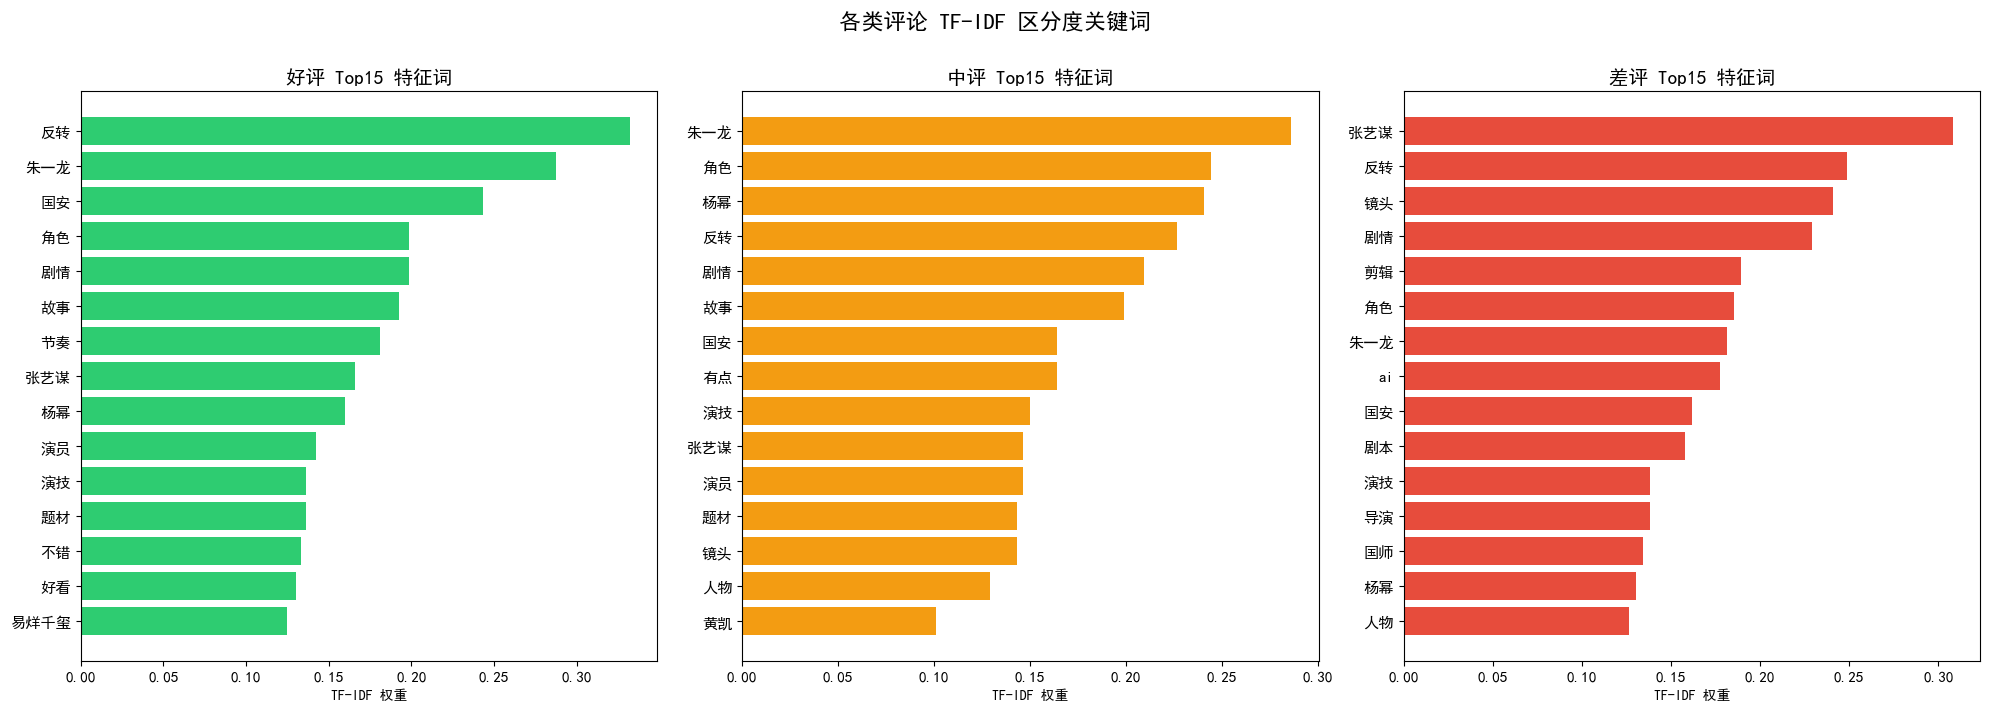

✅ 已保存：TFIDF_区分度关键词.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    words = [class_features[j] for j in top_idx]
    weights = [row[j] for j in top_idx]

    axes[idx].barh(words[::-1], weights[::-1], color=meta["color"])
    axes[idx].set_title(f'{meta["label"]} Top15 特征词',
                        fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("TF-IDF 权重")
    axes[idx].tick_params(labelsize=11)

plt.suptitle("各类评论 TF-IDF 区分度关键词", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("TFIDF_区分度关键词.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：TFIDF_区分度关键词.png")

## 2. 高频词对比柱状图

取全局 Top 20 高频词，展示同一个词在好/中/差三类中的频率差异。

纵轴已归一化为「每400条评论中的出现次数」，消除各类样本量差异的影响。

发现主要围绕着：“反转的剧情” 和 各个演员。

节奏比较好，但很多吐槽剪辑混乱跳切。

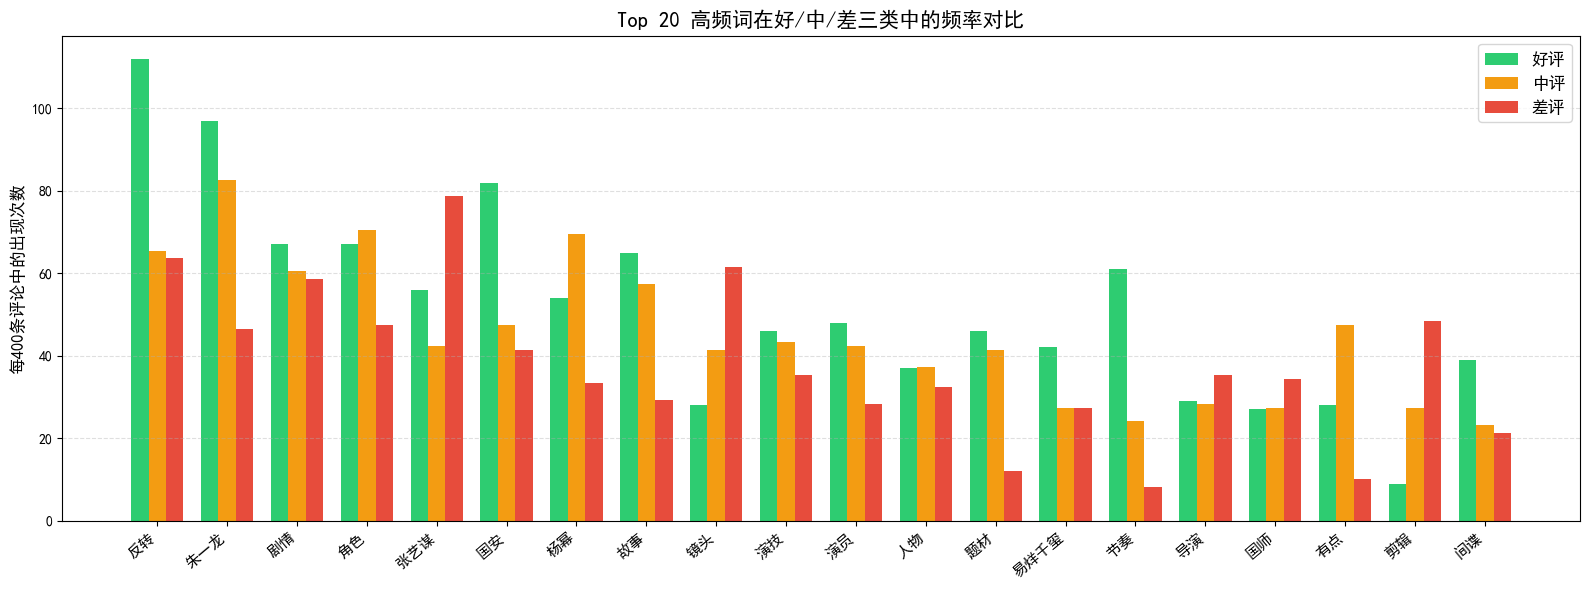

✅ 已保存：高频词_三类对比.png


In [6]:
freq_by_type = {}
for t in type_order:
    freq_by_type[t] = get_word_freq(df[df["comment_type"] == t]["tokens"])

global_freq = get_word_freq(df["tokens"])
top20_words = [w for w, _ in global_freq.most_common(20)]

x = np.arange(len(top20_words))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, t in enumerate(type_order):
    meta = TYPE_META[t]
    n_docs = (df["comment_type"] == t).sum()
    rates = [freq_by_type[t].get(w, 0) / n_docs * 400 for w in top20_words]
    ax.bar(x + i * width, rates, width, label=meta["label"], color=meta["color"])

ax.set_xticks(x + width)
ax.set_xticklabels(top20_words, fontsize=11, rotation=40, ha="right")
ax.set_ylabel("每400条评论中的出现次数", fontsize=12)
ax.set_title("Top 20 高频词在好/中/差三类中的频率对比", fontsize=15)
ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("高频词_三类对比.png", dpi=150)
plt.show()
print("\u2705 已保存：高频词_三类对比.png")

### 3. LDA 主题挖掘（分别对好评和差评）

In [7]:
def discover_topics(texts, n_topics=3, n_top_words=10):
    """
    针对输入的文本列表，训练 LDA 主题模型并提取高频特征词
    """
    # 1. 文本向量化 (使用词频，忽略极低频和极高频词)
    tf_vectorizer = CountVectorizer(max_features=800, min_df=3, max_df=0.85)
    tf = tf_vectorizer.fit_transform(texts)
    
    # 2. 训练 LDA 模型
    lda = LatentDirichletAllocation(
        n_components=n_topics, 
        max_iter=20,
        learning_method='online',
        random_state=RANDOM_STATE
    )
    lda.fit(tf)
    
    # 3. 提取并打印每个主题的核心词
    feature_names = tf_vectorizer.get_feature_names_out()
    topics_words = []
    
    print(f"--- 成功提取 {n_topics} 个潜在主题 ---")
    for topic_idx, topic in enumerate(lda.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics_words.append(top_features)
        print(f"主题 #{topic_idx + 1}: {' | '.join(top_features)}")
        
    return tf_vectorizer, tf, lda, topics_words


挖掘好评/差评主题 (好评到底在夸什么？差评到底在骂什么？)

“反转剧情” 两面评价：好评认为反转精妙绝伦，差评认为反转毫无逻辑。

好评：朱一龙（黄凯）易烊千玺（严迪）等演员

差评：镜头、剪辑、对张艺谋导演有些失望

In [8]:
print("【好评主题分析】")
# 根据你的好评量，假设提取 3 个主题，每个主题看前 12 个词
good_tf_vectorizer, good_tf, good_lda, good_topics = discover_topics(
    df_good["tokens"], n_topics=3, n_top_words=12
)

print("\n【差评主题分析】")
# 同样提取 3 个主题
bad_tf_vectorizer, bad_tf, bad_lda, bad_topics = discover_topics(
    df_bad["tokens"], n_topics=3, n_top_words=12
)


【好评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 黄凯 | 为了 | 人性 | 唯一 | 最大 | 严迪 | 朱一龙 | 国安 | 人物 | 出轨 | 女特务 | 牺牲
主题 #2: 朱一龙 | 反转 | 杨幂 | 节奏 | 角色 | 国安 | 剧情 | 张艺谋 | 演员 | 易烊千玺 | 演技 | 有点
主题 #3: 反转 | 谍战 | 国安 | 故事 | 题材 | 深圳 | 一直 | 惊蛰无声 | 以为 | 动作 | 情节 | 结尾

【差评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 反转 | 张艺谋 | 剪辑 | ai | 镜头 | 逻辑 | 惊蛰无声 | 剧情 | 更是 | 谍战 | 毫无 | 人物
主题 #2: 国师 | 角色 | 张艺谋 | 朱一龙 | 不能 | 国安 | 老谋子 | 电视剧 | 镜头 | 拍出 | 春节 | bgm
主题 #3: 国安 | 剧情 | 教育 | 间谍 | 必要 | 台词 | 为了 | 烂片 | 双面 | 发现 | 身份 | 出轨


使用 pyLDAvis 进行交互式可视化 (以好评为例)

In [9]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

# 可视化好评的主题分布
good_vis = pyLDAvis.lda_model.prepare(good_lda, good_tf, good_tf_vectorizer)
display(good_vis)

# 可以复制这一段代码，将 good 替换为 bad，单独再画一个差评的交互图。


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.124828 -0.085649       1        1  50.132068
0     -0.139757 -0.060850       2        1  25.380545
2      0.014929  0.146499       3        1  24.487387, topic_info=     Term       Freq      Total Category  logprob  loglift
704    谍战  37.000000  37.000000  Default  30.0000  30.0000
207    反转  92.000000  92.000000  Default  29.0000  29.0000
94     人性  18.000000  18.000000  Default  28.0000  28.0000
539    演员  40.000000  40.000000  Default  27.0000  27.0000
234    唯一  19.000000  19.000000  Default  26.0000  26.0000
..    ...        ...        ...      ...      ...      ...
127    值得   8.573153  12.771093   Topic3  -5.1474   1.0085
62     严迪   9.187676  28.624395   Topic3  -5.0781   0.2706
458  易烊千玺   9.718281  56.799767   Topic3  -5.0220  -0.3585
765    间谍   8.931989  33.392132   Topic3  -5.1064   0.0883
348    张译   8.664927  20.738288   Topic3  -5.1367   0.5343

[192 rows x 6 columns], token_table=      Topic      Freq Term
term                      
4         1  0.920159  emo
5         1  0.096709   mv
5         2  0.870381   mv
22        1  0.239364   一直
22        2  0.047873   一直
...     ...       ...  ...
791       2  0.772416   高压
797       1  0.360991   黄凯
797       2  0.593057   黄凯
797       3  0.025785   黄凯
799       3  0.830527   默默

[250 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 3])

### 4. 结合 votes_count 的平方根加权关键词分析

好评：题材与叙事节奏的商业胜利（国安: 354 / 节奏: 278 / 题材: 210）

差评：“短剧化”的终极审美侮辱（张艺谋: 614 / 剧情: 600 / 镜头: 571 / 剪辑: 419 / 短剧: 308）

In [10]:
def get_weighted_top_words(df, top_n=15):
    """计算按获赞数加权后的高频词"""
    weighted_freq = Counter()
    
    for _, row in df.iterrows():
        # 基础权重设为 1，加上点赞数
        weight = int(row.get('votes_count', 0)) + 1 
        tokens = str(row['tokens']).split()
        for word in tokens:
            weighted_freq[word] += weight ** 0.5
            
    return weighted_freq.most_common(top_n)

print("【最具大众共鸣的好评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_good, 12):
    print(f"{word}: {score:.2f} 声量")

print("\n【最具大众共鸣的差评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_bad, 12):
    print(f"{word}: {score:.2f} 声量")


【最具大众共鸣的好评词汇（含点赞加权）】
反转: 400.17 声量
国安: 354.89 声量
剧情: 340.22 声量
易烊千玺: 310.37 声量
朱一龙: 306.35 声量
节奏: 278.35 声量
角色: 275.83 声量
故事: 245.17 声量
好看: 226.57 声量
张艺谋: 221.16 声量
题材: 210.15 声量
杨幂: 195.22 声量

【最具大众共鸣的差评词汇（含点赞加权）】
张艺谋: 614.03 声量
剧情: 600.68 声量
镜头: 571.21 声量
剧本: 447.27 声量
剪辑: 419.00 声量
反转: 413.26 声量
易烊千玺: 385.88 声量
台词: 343.07 声量
角色: 319.01 声量
国安: 310.65 声量
短剧: 308.76 声量
杨幂: 301.51 声量
